# Final Project

#### Imports

In [8]:
from fileinput import filename

import torch
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision.transforms import v2
import matplotlib.pyplot as plt
import string
import time
import os

### Task A - Initial Setup

#### Loading Dataset
b) Download the EMNIST dataset. Note that it contains 6 variants, so called splits, which differ in size and contents. For the first half of the project, you should be using the ‘letters’ split. After loading the dataset, plot a random selection of image samples and the corresponding labels (similar to Figure 1.).

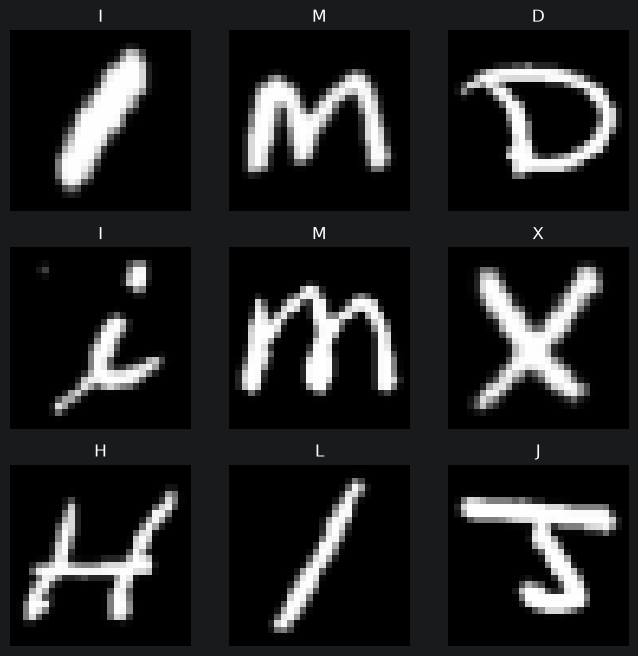

In [9]:
training_data = datasets.EMNIST(
    root="data",
    split="letters",
    train=True,
    download=True,
    transform=v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])
)

test_data = datasets.EMNIST(
    root="data",
    split="letters",
    train=False,
    download=True,
    transform=v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])
)

letters = ["N/A"] + list(string.ascii_uppercase)

figure = plt.figure(figsize=(8, 8))
cols, rows = 3, 3
for i in range(1, cols * rows + 1):
    sample_idx = torch.randint(len(training_data), size=(1,)).item()
    img, label = training_data[sample_idx]
    figure.add_subplot(rows, cols, i)
    plt.title(letters[label])
    plt.axis("off")
    plt.imshow(img.squeeze().T, cmap="gray")
plt.show()

#### Basic learning functionality
c) Implement a program that defines the simple CNN model depicted in see Figure 2. and trains letter classification on the loaded dataset from step b). Implement two functions that use the given model and respective dataset for training and testing. Using cross entropy loss can be a convenient loss function, since it does not require normalized input. In addition, your program should visualize (plot) the training loss and record the total training time.

##### Create Data Loader

In [10]:
batch_size = 512

training_loader = DataLoader(
    training_data,
    batch_size=batch_size,
    shuffle=True,
)

test_loader = DataLoader(
    test_data,
    batch_size=batch_size,
    shuffle=False,
)


##### Define CNN with training and testing functions

In [11]:
class Model:
    def __init__(self, model, learning_rate, batch_size, description="simple-cnn"):
        self.model = model
        self.criterion = torch.nn.CrossEntropyLoss()
        self.optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
        self.learning_rate = learning_rate
        self.batch_size = batch_size
        self.layers = sum(1 for _ in model.modules()) - 1
        self.description = description

    #__TRAINING FUNCTION__
    def train(self, loader):
        self.model.train()

        running_loss = 0
        batch_losses = []

        for images, labels in loader:
            labels = labels - 1

            self.optimizer.zero_grad()

            outputs = self.model(images)
            loss = self.criterion(outputs, labels)

            loss.backward()
            self.optimizer.step()

            running_loss += loss.item()
            batch_losses.append(loss.item())

        average_loss = running_loss / len(loader)

        return average_loss, batch_losses

    #__TESTING FUNCTION__
    def test(self, loader):
        self.model.eval()

        correct = 0
        total = 0

        with torch.no_grad():
            for images, labels in loader:
                labels = labels - 1

                outputs = self.model(images)
                predictions = outputs.argmax(dim = 1)

                correct += (predictions == labels).sum().item()
                total += labels.size(0)

        accuracy = 100 * correct / total
        return accuracy

    #__HELPER FUNCTION TO SAVE MODEL__
    def save_model(self, loss_history=None, epochs=0, model_dir="models", figs_dir="figs", show_plot=False):
        os.makedirs(model_dir, exist_ok=True)
        os.makedirs(figs_dir, exist_ok=True)

        filename = (
            f"cnn_"
            f"{self.description}_"
            f"epo_{epochs}_"
            f"lnr_{self.learning_rate}_"
            f"bts_{self.batch_size}_"
            f"lay_{self.layers}_"
            f"opt_Adam_"
            f"tim_{time.time()}"
        )

        path = os.path.join(model_dir, filename + ".pth")
        torch.save(self.model.state_dict(), path)

        if loss_history is not None and epochs != 0:
            figpath = os.path.join(figs_dir, f"{filename}_loss_history.png")
            save_loss_plot(loss_history, filename=figpath, show_plot=show_plot)
            print(f"Plot saved to: {figpath}")

        print(f"Model saved to: {path}")


##### Training Loop

In [12]:
def training_loop(model, epochs):

    loss_history = []

    start_time = time.time()

    for epoch in range(epochs):
        avg_loss, batch_losses = model.train(training_loader)

        loss_history.append(batch_losses)

        accuracy = model.test(test_loader)

        print(
            f"Epoch {epoch+1}/{epochs}\n"
            f"Loss {avg_loss:.4f}\n"
            f"Accuracy {accuracy:.2f}%"
        )

    training_time = time.time() - start_time

    print(f"\nTraining time: {training_time:.2f} seconds")

    return loss_history

##### Training Loss Plot

In [13]:
def save_loss_plot(loss_history, filename, show_plot=False):
    plt.figure(figsize=(8, 5))

    for epoch, losses in enumerate(loss_history):
        plt.plot(losses, label=f"Epoch {epoch+1}")

    plt.xlabel("Batch")
    plt.ylabel("Loss")
    plt.title("Training Loss per Batch")
    plt.legend()
    plt.savefig(filename)

    if show_plot:
        plt.show()

#### Define Simple CNN Model

In [14]:
simple_architecture = torch.nn.Sequential(
    torch.nn.Conv2d(in_channels=1, out_channels=8, kernel_size=3, padding=1),
    torch.nn.ReLU(),
    torch.nn.MaxPool2d(kernel_size=2, stride=2),
    torch.nn.Flatten(),
    torch.nn.Linear(in_features= 8 * 14 * 14, out_features=26),
)

#simple_model = Model(simple_architecture, learning_rate=0.001, batch_size=batch_size, description="simple-cnn")
#simple_model.save_model(loss_history=training_loop(simple_model, epochs=5), epochs=5)

b) Our initial model is very simple. Your task is to define and train a new, more complex model by **adding more layers**.

In [15]:
architecture_1 = torch.nn.Sequential(
    torch.nn.Conv2d(in_channels=1, out_channels=8, kernel_size=3, padding=1),
    torch.nn.ReLU(),
    torch.nn.Conv2d(in_channels=8, out_channels=8, kernel_size=3, padding=1),
    torch.nn.ReLU(),
    torch.nn.MaxPool2d(kernel_size=2, stride=2),
    torch.nn.Flatten(),
    torch.nn.Linear(in_features= 8 * 14 * 14, out_features=26),
)

#model_1 = Model(architecture_1, learning_rate=0.001, batch_size=batch_size, description="pooling-at-end")
#model_1.save_model(loss_history=training_loop(model_1, epochs=5), epochs=5)

In [16]:
architecture_2 = torch.nn.Sequential(
    torch.nn.Conv2d(in_channels=1, out_channels=8, kernel_size=3, padding=1),
    torch.nn.ReLU(),
    torch.nn.MaxPool2d(kernel_size=2, stride=2),
    torch.nn.Conv2d(in_channels=8, out_channels=16, kernel_size=3, padding=1),
    torch.nn.ReLU(),
    torch.nn.MaxPool2d(kernel_size=2, stride=2),
    torch.nn.Flatten(),
    torch.nn.Linear(in_features= 16 * 7 * 7, out_features=26),
)

#model_2 = Model(architecture_2, learning_rate=0.001, batch_size=batch_size, description="pooling-between")
#model_2.save_model(loss_history=training_loop(model_2, epochs=5), epochs=5)

In [17]:
architecture_3 = torch.nn.Sequential(
    torch.nn.Conv2d(in_channels=1, out_channels=8, kernel_size=3, padding=1),
    torch.nn.ReLU(),
    torch.nn.MaxPool2d(kernel_size=2, stride=2),
    torch.nn.Conv2d(in_channels=8, out_channels=16, kernel_size=3, padding=1),
    torch.nn.ReLU(),
    torch.nn.MaxPool2d(kernel_size=2, stride=2),
    torch.nn.Flatten(),
    torch.nn.Linear(in_features= 16 * 7 * 7, out_features=64),
    torch.nn.ReLU(),
    torch.nn.Linear(in_features=64, out_features=26),
)

#model_3 = Model(architecture_3, learning_rate=0.001, batch_size=batch_size, description="more-layers")
#model_3.save_model(loss_history=training_loop(model_3, epochs=5), epochs=5)

c) You should also experiment with changing the number of output channels (feature maps) and the
size of the convolution kernel. Document your experiment results and briefly explain the meaning of
feature maps.

Epoch 1/5
Loss 1.2708
Accuracy 79.06%
Epoch 2/5
Loss 0.5171
Accuracy 86.67%
Epoch 3/5
Loss 0.3751
Accuracy 89.06%
Epoch 4/5
Loss 0.3239
Accuracy 89.62%
Epoch 5/5
Loss 0.2932
Accuracy 90.18%

Training time: 343.74 seconds
Plot saved to: figs/cnn_more-feature-maps_epo_5_lnr_0.001_bts_512_lay_10_opt_Adam_tim_1786372963.8490753_loss_history.png
Model saved to: models/cnn_more-feature-maps_epo_5_lnr_0.001_bts_512_lay_10_opt_Adam_tim_1786372963.8490753.pth


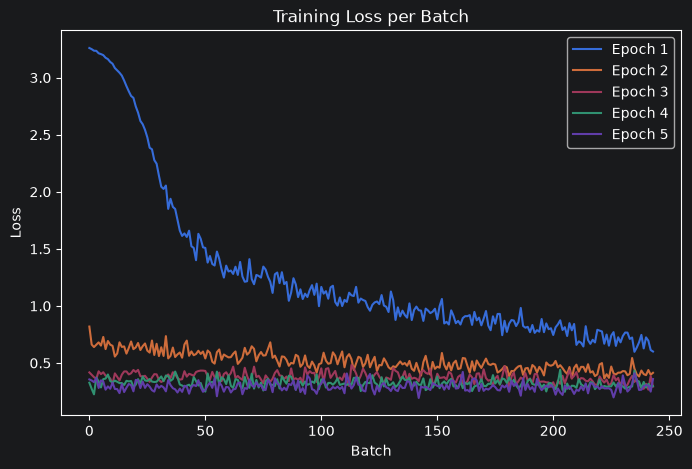

In [18]:
architecture_4 = torch.nn.Sequential(
    torch.nn.Conv2d(in_channels=1, out_channels=16, kernel_size=3, padding=1),
    torch.nn.ReLU(),
    torch.nn.MaxPool2d(kernel_size=2, stride=2),
    torch.nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1),
    torch.nn.ReLU(),
    torch.nn.MaxPool2d(kernel_size=2, stride=2),
    torch.nn.Flatten(),
    torch.nn.Linear(in_features= 32 * 7 * 7, out_features=64),
    torch.nn.ReLU(),
    torch.nn.Linear(in_features=64, out_features=26),
)
model_4 = Model(architecture_4, learning_rate=0.001, batch_size=batch_size, description="more-feature-maps")
model_4.save_model(loss_history=training_loop(model_4, epochs=5), epochs=5)

In [19]:
architecture_5 = torch.nn.Sequential(
    torch.nn.Conv2d(in_channels=1, out_channels=8, kernel_size=5, padding=2),
    torch.nn.ReLU(),
    torch.nn.MaxPool2d(kernel_size=3, stride=2),
    torch.nn.Conv2d(in_channels=8, out_channels=16, kernel_size=5, padding=2),
    torch.nn.ReLU(),
    torch.nn.MaxPool2d(kernel_size=3, stride=2),
    torch.nn.Flatten(),
    torch.nn.Linear(in_features= 16 * 7 * 7, out_features=64),
    torch.nn.ReLU(),
    torch.nn.Linear(in_features=64, out_features=26),
)

model_5 = Model(architecture_5, learning_rate=0.001, batch_size=batch_size, description="larger-kernels")
model_5.save_model(loss_history=training_loop(model_5, epochs=5), epochs=5)



RuntimeError: mat1 and mat2 shapes cannot be multiplied (512x576 and 784x64)